In [1]:
import numpy as np
import matplotlib.pyplot as plt
import hmf 
import powerbox as pbox

In [50]:
from scipy.interpolate import InterpolatedUnivariateSpline as spline
import numpy as np

# Set up a MassFunction instance to access its cosmological power-spectrum
mf = hmf.MassFunction(z=0)

# Generate a callable function that returns the cosmological power spectrum.
spl = spline(np.log(mf.k),np.log(mf.power),k=2)
power = lambda k : np.exp(spl(np.log(k)))

# Create the power-box instance. The boxlength is in inverse units of the k of which pk is a function, i.e.
# Mpc/h in this case.
pb = pbox.LogNormalPowerBox(N=256, dim=3, pk = power, boxlength= 500., seed=1234)

In [51]:
mf = hmf.MassFunction(z=0)

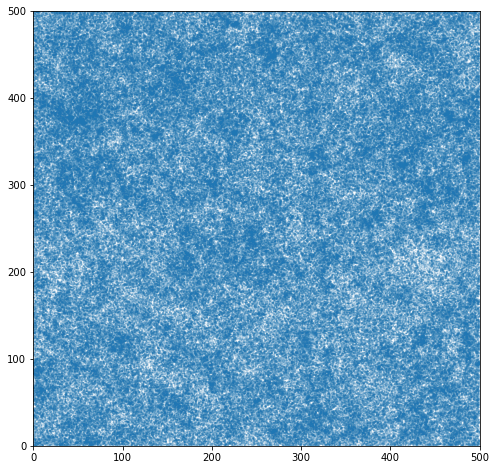

In [52]:
particles = pb.create_discrete_sample(nbar=0.003,min_at_zero=True)

plt.figure(figsize=(8,8))
plt.scatter(particles[:,0],particles[:,1],s=np.sqrt(100./particles[:,2]),alpha=0.2)
plt.xlim(0,500)
plt.ylim(0,500)
plt.show()

(374491, 3)

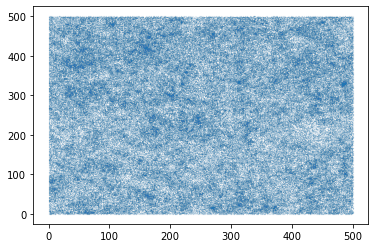

In [53]:
plt.scatter(particles[:,0],particles[:,1],s=0.001)
np.shape(particles)

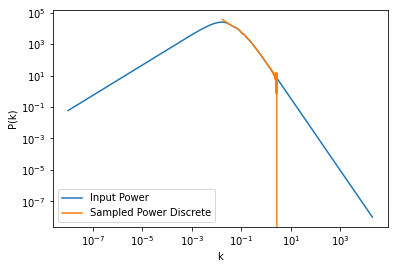

In [54]:
p_k_sample, kbins_sample = pbox.get_power(particles, pb.boxlength,N=pb.N)

plt.plot(mf.k,mf.power,label="Input Power")
plt.plot(kbins_sample,p_k_sample,label="Sampled Power Discrete")
plt.xscale('log')
plt.yscale('log')

plt.ylabel("P(k)")
plt.xlabel("k")
plt.legend()
plt.show()

In [38]:
samples=10*np.random.rand(10,2)
samples2=10*np.random.rand(100,2)
samples1=10*np.random.rand(100,2)

In [39]:
np.shape(particles)

(374491, 3)

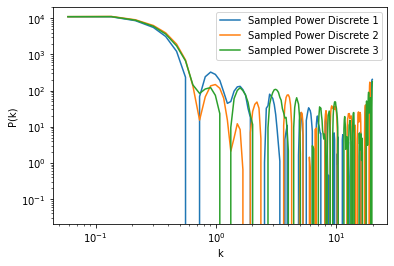

In [40]:
p_k_sample, kbins_sample = pbox.get_power(samples, 80/0.7, N=512)
p_k_sample1, kbins_sample1 = pbox.get_power(samples1, 80/0.7, N=512)
p_k_sample2, kbins_sample2 = pbox.get_power(samples2, 80/0.7, N=512)

#plt.plot(mf.k,mf.power,label="Input Power")
plt.plot(kbins_sample,p_k_sample,label="Sampled Power Discrete 1")
plt.plot(kbins_sample1,p_k_sample1,label="Sampled Power Discrete 2")
plt.plot(kbins_sample2,p_k_sample2,label="Sampled Power Discrete 3")
plt.xscale('log')
plt.yscale('log')

plt.ylabel("P(k)")
plt.xlabel("k")
plt.legend()
plt.show()